### Análisis de datos II
## Reducción de dimensionalidad

En esta notebook se ejemplifica la reducción de dimensionalidad sobre el dataset de [automóbiles](https://uci-ics-mlr-prod.aws.uci.edu/dataset/10/automobile).
Se aplican las técnicas PCA y SVD.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

---
### DATASET

In [2]:
columns = [
    "symboling",
    "normalized-losses",
    "make",
    "fuel-type",
    "aspiration",
    "num-of-doors",
    "body-style",
    "drive-wheels",
    "engine-location",
    "wheel-base",
    "length",
    "width",
    "height",
    "curb-weight",
    "engine-type",
    "num-of-cylinders",
    "engine-size",
    "fuel-system",
    "bore",
    "stroke",
    "compression-ratio",
    "horsepower",
    "peak-rpm",
    "city-mpg",
    "highway-mpg",
    "price"
]

auto = pd.read_csv(
    '../datasets/automobile/imports-85.data',
    header=None,
    names=columns,
    na_values="?"
)

auto.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0


In [3]:
auto.shape

(205, 26)

In [4]:
# eliminamos filas con target null.
auto = auto.dropna(subset=["price"])
auto = auto[auto["price"] != 0].reset_index(drop=True)

target = auto["price"].copy()
X = auto.drop(columns="price")

### Pipeline

- separar numéricas y categóricas
- imputar faltantes
- escalar las numéricas
- hacer one-hot encoding de las categóricas (para simplificar)
- aplicar PCA

In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

In [6]:
# Identificar tipos de variables
numeric_cols = X.select_dtypes(include="number").columns
categorical_cols = X.select_dtypes(exclude="number").columns

In [7]:
# Preprocesamiento
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            numeric_cols
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]),
            categorical_cols
        )
    ]
)

X_processed = preprocessor.fit_transform(X)

---
### PCA

In [8]:
from sklearn.decomposition import PCA

pca = PCA(n_components=20)
X_pca = pca.fit_transform(X_processed)
X_pca.shape

(201, 20)

#### Explicamos la varianza

In [9]:
# varianza explicada por cada componente
explained_var = pca.explained_variance_ratio_

# varianza acumulada
cumulative_var = np.cumsum(explained_var)

# varianza total
total_var = explained_var.sum()

n_components = len(explained_var)
componentes = np.arange(1, n_components + 1)

In [10]:
print(f'Varianza explicada por cada componente:\n{explained_var}')

Varianza explicada por cada componente:
[0.37597036 0.16859674 0.08285472 0.05737041 0.04665933 0.03188708
 0.03006272 0.02582326 0.02005398 0.01970404 0.01678892 0.01358466
 0.01224497 0.00978027 0.00814317 0.0078215  0.00711283 0.00625849
 0.00540465 0.00510264]


In [11]:
print(f'Varianza total:\n{total_var}')

Varianza total:
0.9512247372060427


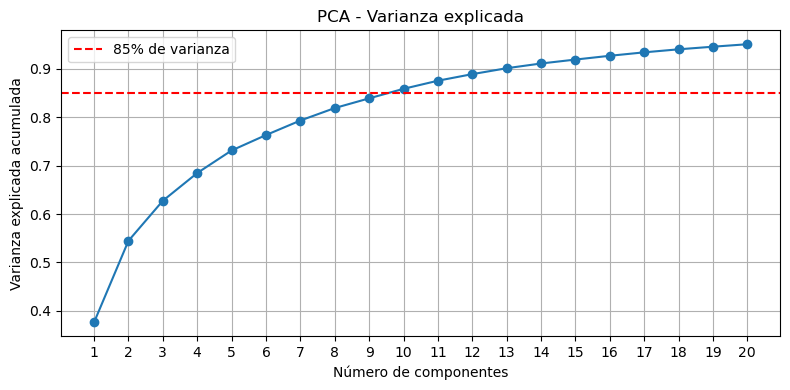

Varianza explicada acumulada:
[0.37597036 0.5445671  0.62742181 0.68479222 0.73145155 0.76333863
 0.79340135 0.81922461 0.83927859 0.85898263 0.87577155 0.88935621
 0.90160119 0.91138146 0.91952463 0.92734613 0.93445896 0.94071745
 0.9461221  0.95122474]


In [12]:
plt.figure(figsize=(8, 4))
plt.plot(componentes, cumulative_var, marker='o')
plt.xticks(componentes)
plt.xlabel('Número de componentes')
plt.ylabel('Varianza explicada acumulada')
plt.title('PCA - Varianza explicada')
plt.grid(True)
plt.axhline(y=0.85, color='red', linestyle='--', label='85% de varianza')
plt.tight_layout()
plt.legend()
plt.show()

print(f'Varianza explicada acumulada:\n{cumulative_var}')

---
### SVD

In [13]:
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(n_components=20)
#svd = svd.fit(X_processed)
X_svd = svd.fit_transform(X_processed)

In [14]:
# varianza explicada por cada componente
explained_var = svd.explained_variance_ratio_

# varianza acumulada
cumulative_var = np.cumsum(explained_var)

# varianza total
total_var = explained_var.sum()

n_components = len(explained_var)
componentes = np.arange(1, n_components + 1)

In [15]:
print(f'SVD - Varianza explicada por cada componente:\n{explained_var}')

SVD - Varianza explicada por cada componente:
[0.36485491 0.01714333 0.16847484 0.08129684 0.0563755  0.0466523
 0.03073204 0.02998918 0.02579721 0.01979874 0.01967194 0.01634323
 0.01350075 0.01178809 0.00972465 0.00801682 0.00782132 0.00710439
 0.00607207 0.00532151]


In [16]:
print(f'SVD - Varianza total:\n{total_var}')

SVD - Varianza total:
0.9464796738575499


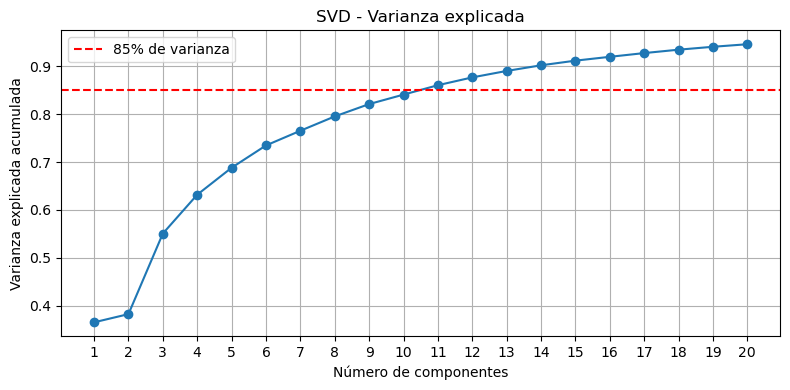

Varianza explicada acumulada:
[0.36485491 0.38199825 0.55047309 0.63176993 0.68814543 0.73479773
 0.76552977 0.79551895 0.82131616 0.84111489 0.86078684 0.87713007
 0.89063082 0.90241891 0.91214357 0.92016038 0.92798171 0.9350861
 0.94115817 0.94647967]


In [17]:
plt.figure(figsize=(8, 4))
plt.plot(componentes, cumulative_var, marker='o')
plt.xticks(componentes)
plt.xlabel('Número de componentes')
plt.ylabel('Varianza explicada acumulada')
plt.title('SVD - Varianza explicada')
plt.grid(True)
plt.axhline(y=0.85, color='red', linestyle='--', label='85% de varianza')
plt.tight_layout()
plt.legend()
plt.show()

print(f'Varianza explicada acumulada:\n{cumulative_var}')